In [3]:
import zipfile
import os

zip_file_path = '/content/archive (2).zip'
output_dir = '/content/'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(output_dir)

print(f"'{zip_file_path}' unzipped to '{output_dir}'")
print("Files in output directory:")
print(os.listdir(output_dir))


'/content/archive (2).zip' unzipped to '/content/'
Files in output directory:
['.config', 'data.csv', 'archive (2).zip', 'sample_data']


In [4]:
import pandas as pd


df = pd.DataFrame(pd.read_csv('/content/data.csv'))

# Verinin ilk 5 satırını görelim
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# Yeni Bölüm

In [5]:
# 1. Gereksiz sütunları silelim (id ve varsa isimsiz boş sütun)
# Sende 32 sütun görünüyor, muhtemelen en sondaki boş.
df = df.drop(['id'], axis=1)
if 'Unnamed: 32' in df.columns:
    df = df.drop(['Unnamed: 32'], axis=1)

# 2. Diagnosis (M ve B) harflerini 1 ve 0 yapalım
# M (Kötü huylu) = 1, B (İyi huylu) = 0 olsun
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Kontrol edelim
df.head()


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


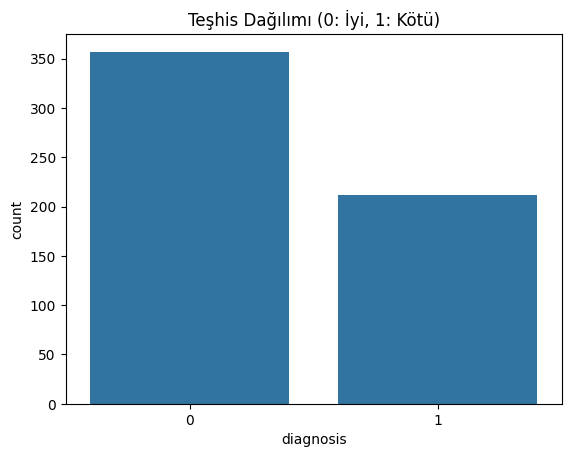

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Kaç kişi hasta (1), kaç kişi sağlıklı (0) görelim
sns.countplot(x='diagnosis', data=df)
plt.title("Teşhis Dağılımı (0: İyi, 1: Kötü)")
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# X: Özellikler (Ölçümler), y: Hedef (Teşhis)
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# Verinin %20'sini test (sınav) için ayıralım
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Sayıları ölçeklendirelim (Her şey aynı boyuta gelsin)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Veri başarıyla bölündü ve ölçeklendirildi!")

Veri başarıyla bölündü ve ölçeklendirildi!


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 1. Algoritma: Logistic Regression (Lojistik Regresyon)
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train) # Modeli eğitiyoruz
lr_pred = lr_model.predict(X_test) # Test verisiyle tahmin yapıyoruz

# 2. Algoritma: Random Forest (Rastgele Orman)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train) # Modeli eğitiyoruz
rf_pred = rf_model.predict(X_test) # Test verisiyle tahmin yapıyoruz

print("Modeller başarıyla eğitildi ve tahminler yapıldı!")

Modeller başarıyla eğitildi ve tahminler yapıldı!



--- Logistic Regression SONUÇLARI ---
Doğruluk (Accuracy) Skoru: %97.37

Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



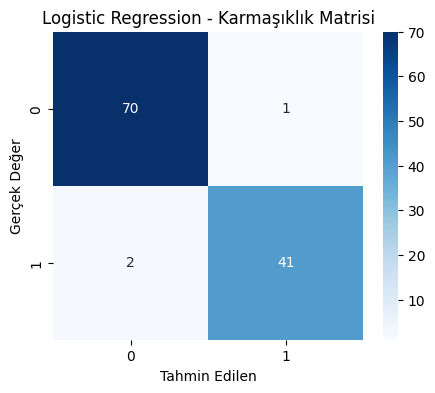


--- Random Forest SONUÇLARI ---
Doğruluk (Accuracy) Skoru: %96.49

Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



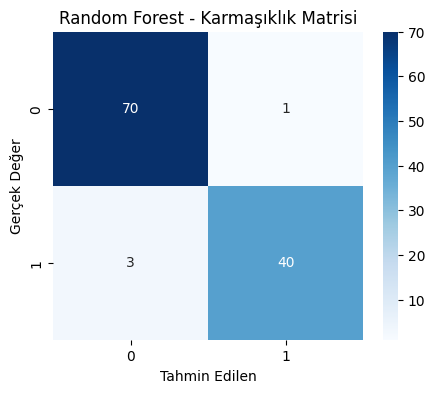

In [9]:
def sonuclari_goster(y_test, y_pred, model_ismi):
    print(f"\n--- {model_ismi} SONUÇLARI ---")
    print(f"Doğruluk (Accuracy) Skoru: %{accuracy_score(y_test, y_pred)*100:.2f}")
    print("\nSınıflandırma Raporu:\n", classification_report(y_test, y_pred))

    # Karmaşıklık Matrisi (Confusion Matrix) Görselleştirme
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_ismi} - Karmaşıklık Matrisi')
    plt.xlabel('Tahmin Edilen')
    plt.ylabel('Gerçek Değer')
    plt.show()

# İki modeli de kıyaslayalım
sonuclari_goster(y_test, lr_pred, "Logistic Regression")
sonuclari_goster(y_test, rf_pred, "Random Forest")

1. Accuracy (Doğruluk) Skoru: 0.9649
2. Precision (Kesinlik) Skoru: 0.9756
3. Recall (Duyarlılık) Skoru: 0.9302
4. F1-Score: 0.9524

--- Confusion Matrix (Karmaşıklık Matrisi) ---
[[70  1]
 [ 3 40]]


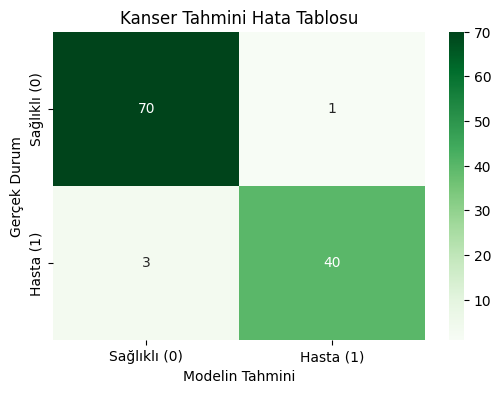

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# --- 1. MODEL EĞİTİMİ VE TEST İŞLEMLERİNİN GERÇEKLEŞTİRİLMESİ ---
# (Bu adımı yukarıda .fit() ve .predict() yaparak yapmıştık, şimdi sonuçları değişkenlere atayalım)
# Örnek olarak Random Forest üzerinden gidelim:
y_pred = rf_pred

# --- 2. MODEL PERFORMANSININ DEĞERLENDİRİLMESİ ---

# A) Accuracy (Doğruluk): Toplam doğru tahmin oranı
acc = accuracy_score(y_test, y_pred)
print(f"1. Accuracy (Doğruluk) Skoru: {acc:.4f}")

# B) Precision (Kesinlik): 'Hasta' dediklerimizin kaçı gerçekten hasta?
prec = precision_score(y_test, y_pred)
print(f"2. Precision (Kesinlik) Skoru: {prec:.4f}")

# C) Recall (Duyarlılık): Gerçek hastaların kaçını doğru teşhis ettik?
rec = recall_score(y_test, y_pred)
print(f"3. Recall (Duyarlılık) Skoru: {rec:.4f}")

# D) F1-Score: Precision ve Recall'un dengeli bir ortalaması
f1 = f1_score(y_test, y_pred)
print(f"4. F1-Score: {f1:.4f}")

# --- 3. CONFUSION MATRIX (KARMAŞIKLIK MATRİSİ) ---
print("\n--- Confusion Matrix (Karmaşıklık Matrisi) ---")
cm = confusion_matrix(y_test, y_pred)
print(cm)


plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Sağlıklı (0)', 'Hasta (1)'], yticklabels=['Sağlıklı (0)', 'Hasta (1)'])
plt.xlabel('Modelin Tahmini')
plt.ylabel('Gerçek Durum')
plt.title('Kanser Tahmini Hata Tablosu')
plt.show()